In [7]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#이미지를 읽어 들이기 위한 라이브러리 추가
import matplotlib.image as mpimg
import matplotlib as mpl
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
#한글처리 -> 코랩에서는 별도로 다시 강의 
plt.rcParams['font.family'] ="NanumGothic"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

In [8]:
X = [8.70153760, 3.90825773, 1.89362433, 3.28730045, 7.39333004, 2.98984649, 2.25757240, 9.84450732, 9.94589513, 5.48321616]
Y = [5.64413093, 3.75876583, 3.87233310, 4.40990425, 6.43845020, 4.02827829, 2.26105955, 7.15768995, 6.29097441, 5.19692852]

<p>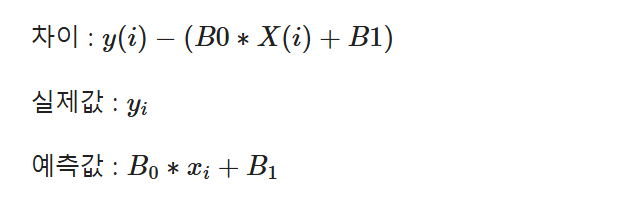</p>

In [9]:
# 우리가 만든 Lossfunction : x,y의 오차를 구하기 위해서 함수 정의
def loss(x,y,beta_0,beta_1):
    n = len(x)
    '''
    x, y, beta_0, beta_1 을 이용해 loss값을 계산한 뒤 리턴
    '''  
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted) ** 2
    total_loss = np.sum(squared_loss)
    total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2)
    return total_loss

In [10]:
beta_0 = 0.41 
beta_1 = 2.61
print(f"우리가 구한 Loss => {loss(X,Y,beta_0,beta_1)}")

y_predicted =>[6.17763042 4.21238567 3.38638598 3.95779318 5.64126532 3.83583706
 3.53560468 6.646248   6.687817   4.85811863]
우리가 구한 Loss => 3.761793403014256


In [11]:
X[:2] , Y[:2]

([8.7015376, 3.90825773], [5.64413093, 3.75876583])

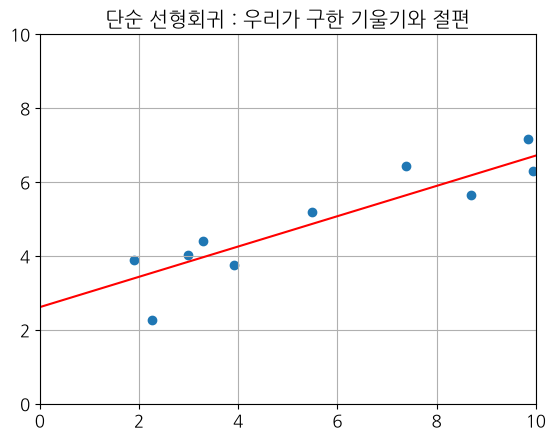

In [12]:
plt.title('단순 선형회귀 : 우리가 구한 기울기와 절편')
# y = beta_0 * x + beta_1 : 직선
plt.plot([0,10],[beta_1,10 * beta_0 + beta_1],c='r')
plt.scatter(X,Y)
plt.xlim(0,10)
plt.ylim(0,10)
plt.grid(True)
plt.show()

<p>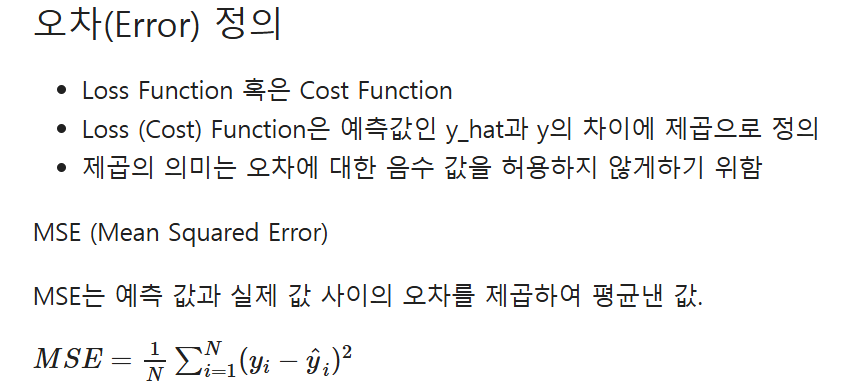</p>

In [13]:
# 연습문제) MSE공식을 적용한 함수  MSE를 만들고 위에서 테스트한
# 기울기(B0)와 절편(B1)을 매개변수로 전달해서 평균제곱오차를 출력하고 
# 그래프로 회귀선을 그려서 시각화 하시오.

In [14]:
def MSE(x,y,beta_0,beta_1):
    n = len(x)
    '''
    x, y, beta_0, beta_1 을 이용해 loss값을 계산한 뒤 리턴
    '''  
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted) ** 2
    total_loss = np.sum(squared_loss)
    total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2) / n
    return total_loss

In [15]:
beta_0 = 0.41 # 기울기
beta_1 = 2.61 # 절편 => Loss: 3.761793
print("MSE: %f" % MSE(X, Y, beta_0, beta_1)) # MSE: 0.376179

y_predicted =>[6.17763042 4.21238567 3.38638598 3.95779318 5.64126532 3.83583706
 3.53560468 6.646248   6.687817   4.85811863]
MSE: 0.376179


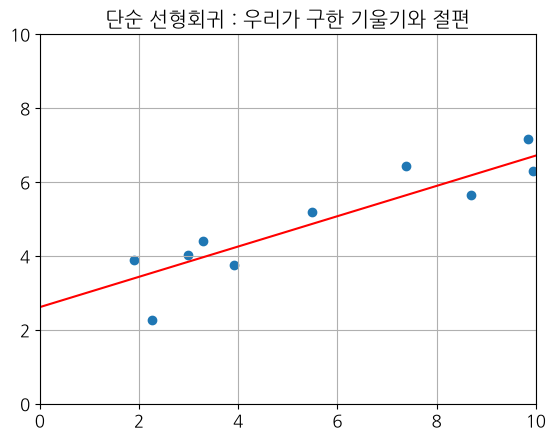

In [16]:
plt.title('단순 선형회귀 : 우리가 구한 기울기와 절편')
# y = beta_0 * x + beta_1 : 직선
#x = [0, 10]   => x축에서 0과 10 두 점을 지정
#y = [beta_1, 10 * beta_0 + beta_1]  => x=0일 때 y = beta_1 , x=10일 때 y = 10 * beta_0 + beta_1
#plot(x,y)를 사용해서 두 점 (0, beta_1) 과 (10, 10beta_0 + beta_1)* 을 연결하는 직선 긋는다.
plt.plot([0,10],[beta_1,10 * beta_0 + beta_1],c='r')
plt.scatter(X,Y)
plt.xlim(0,10)
plt.ylim(0,10)
plt.grid(True)
plt.show()

<p>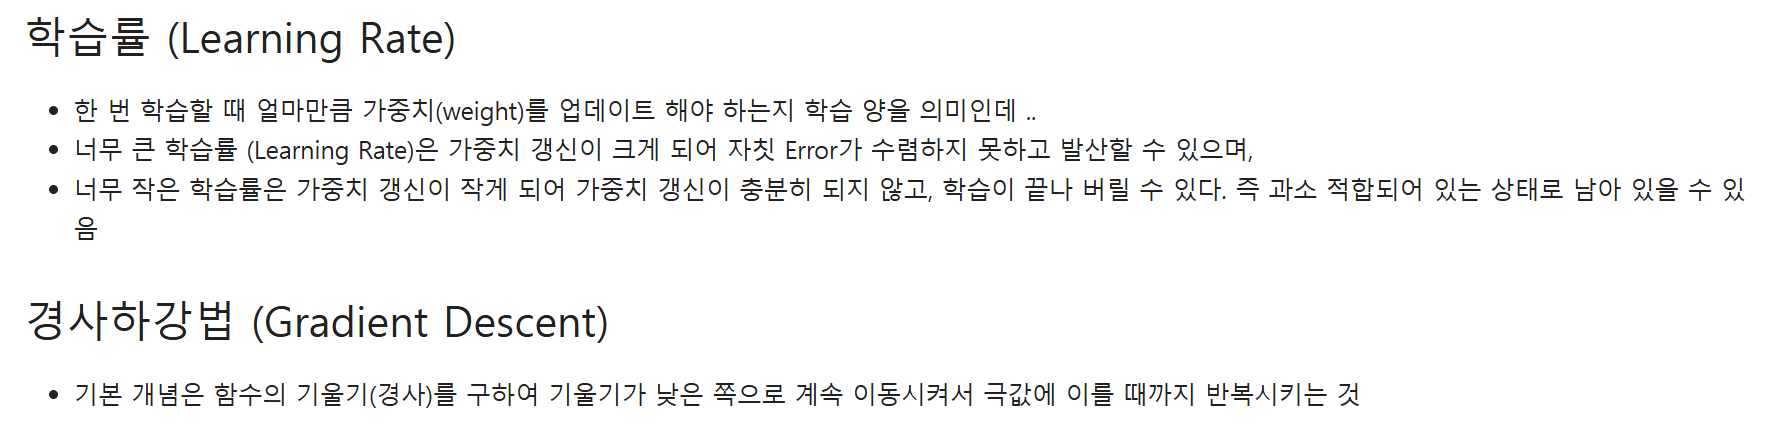</p>

<p>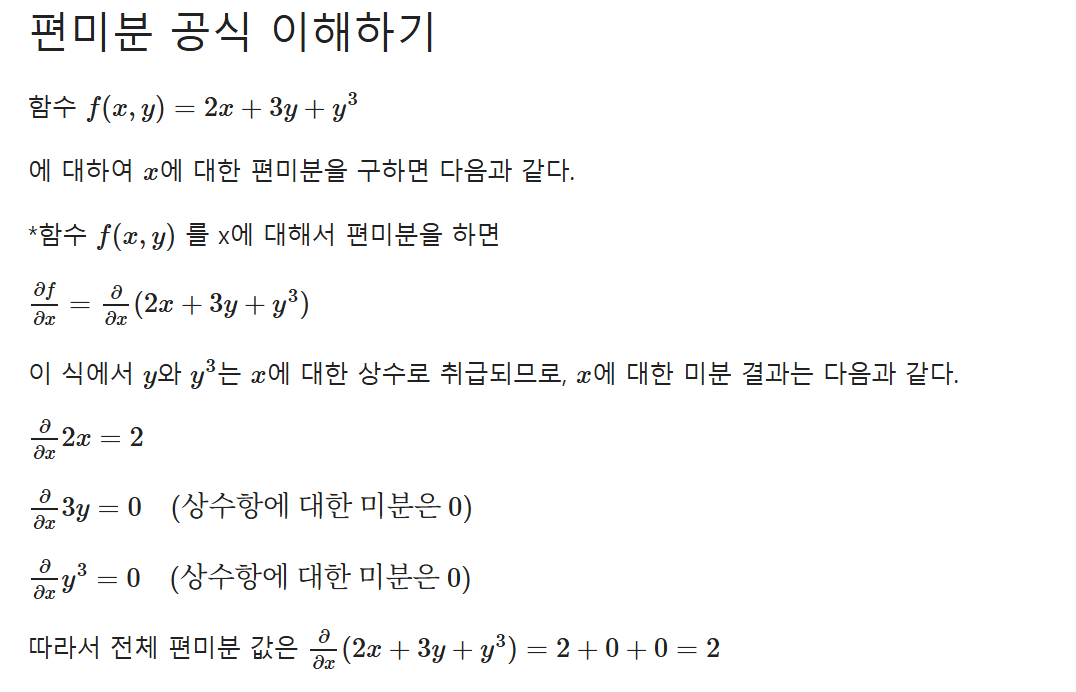</p>

<p>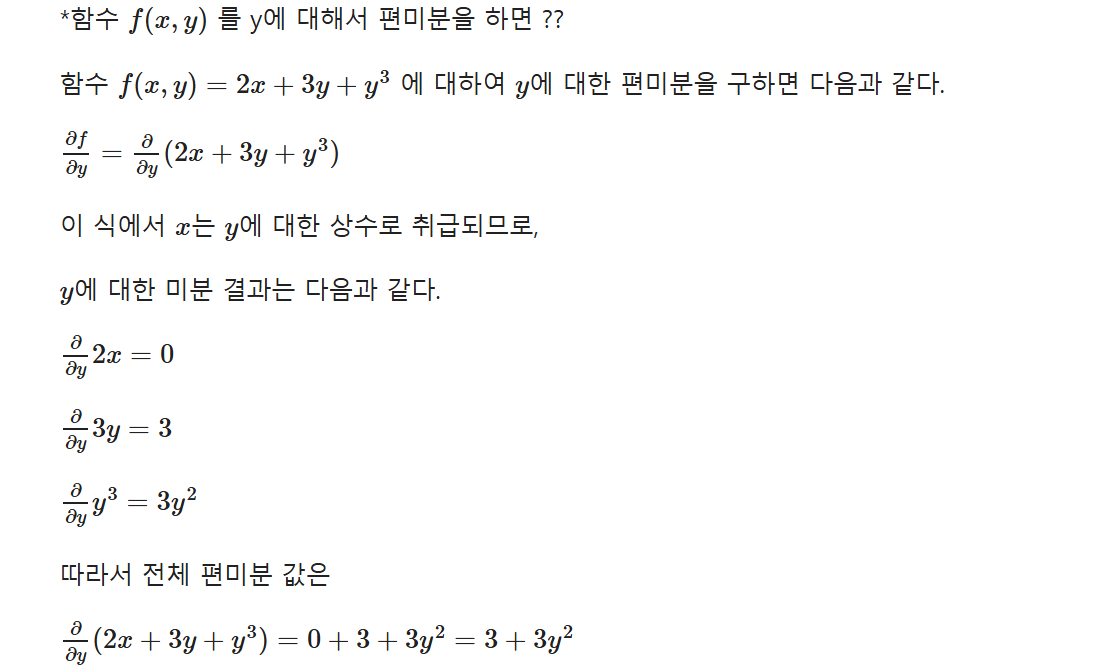</p>

<p>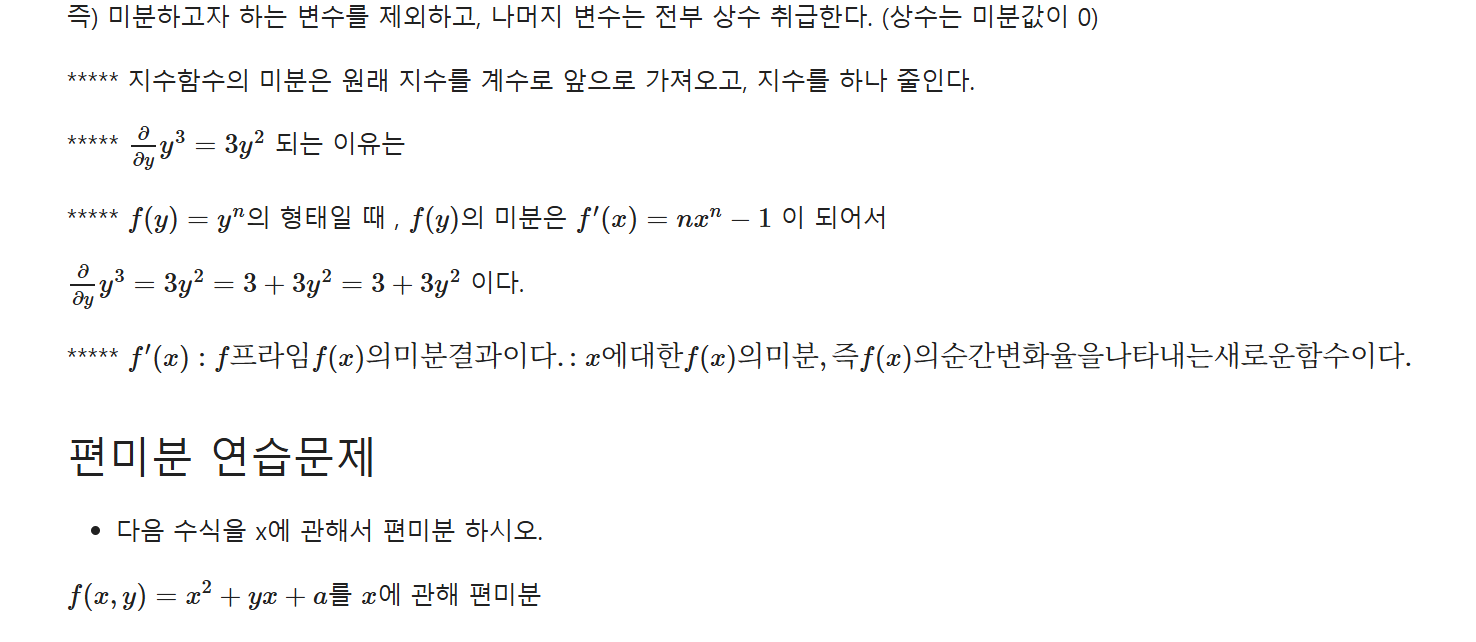</p>

<p>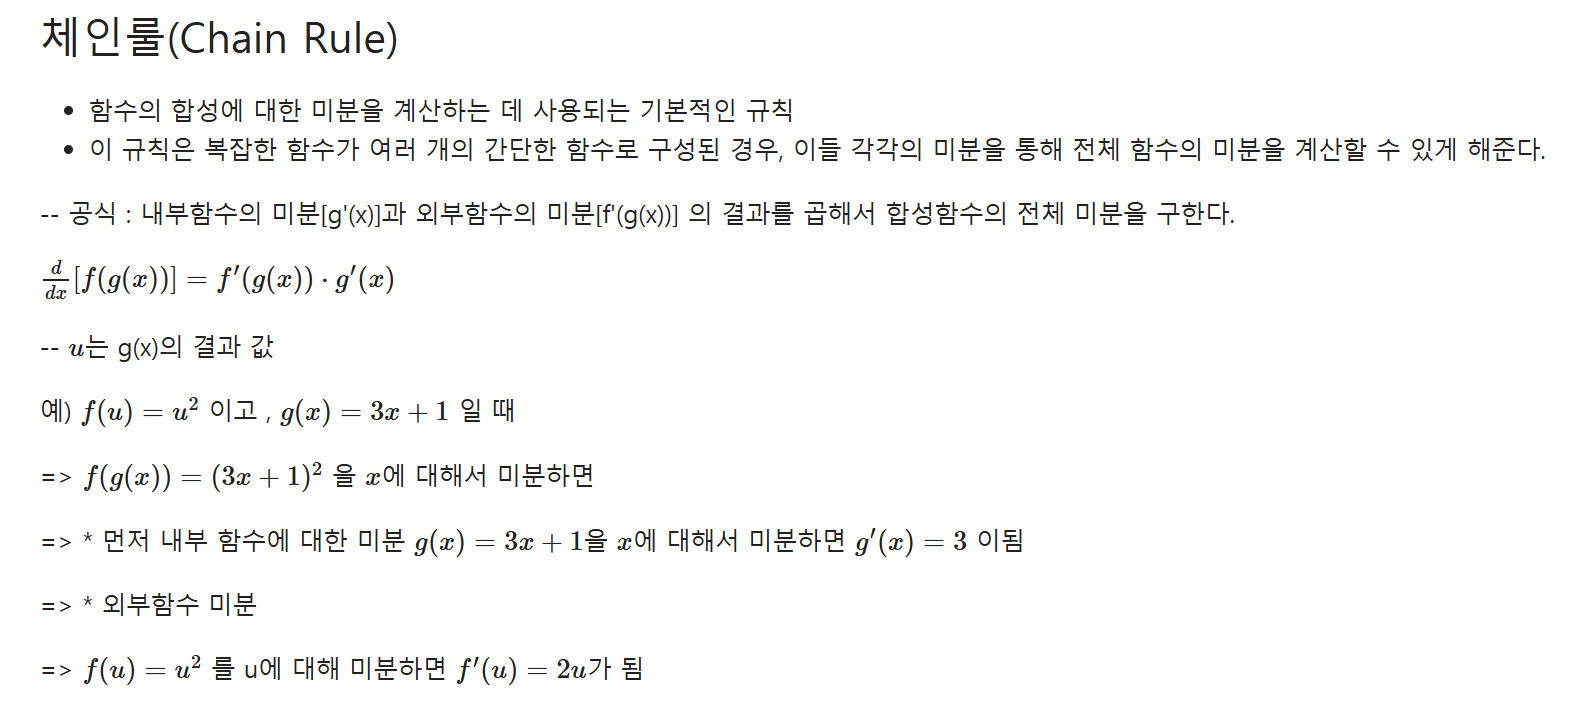</p>

<p>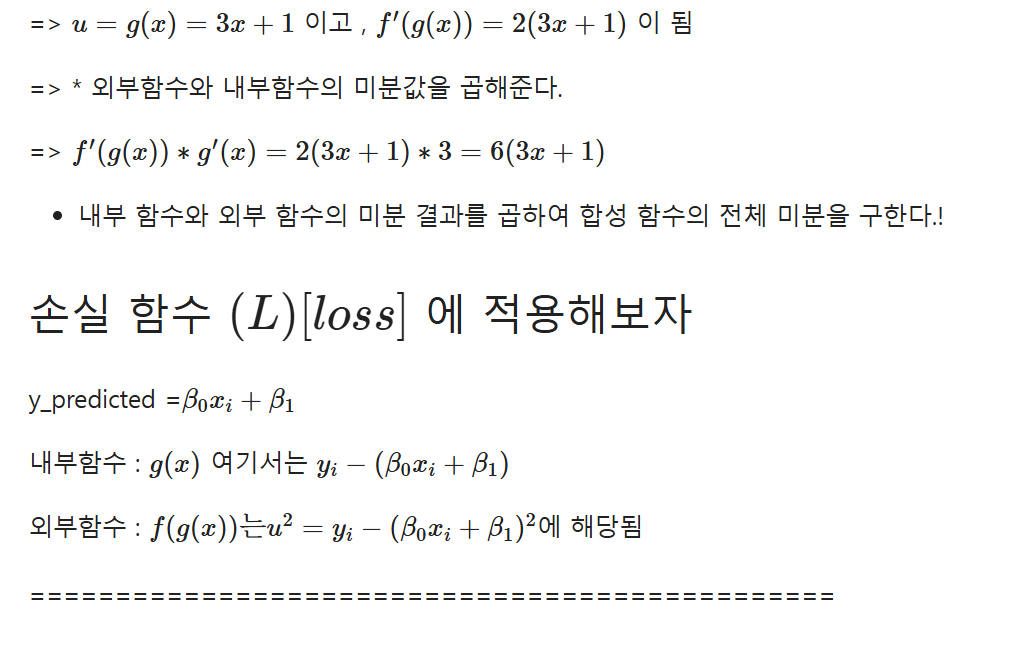</p>

<p>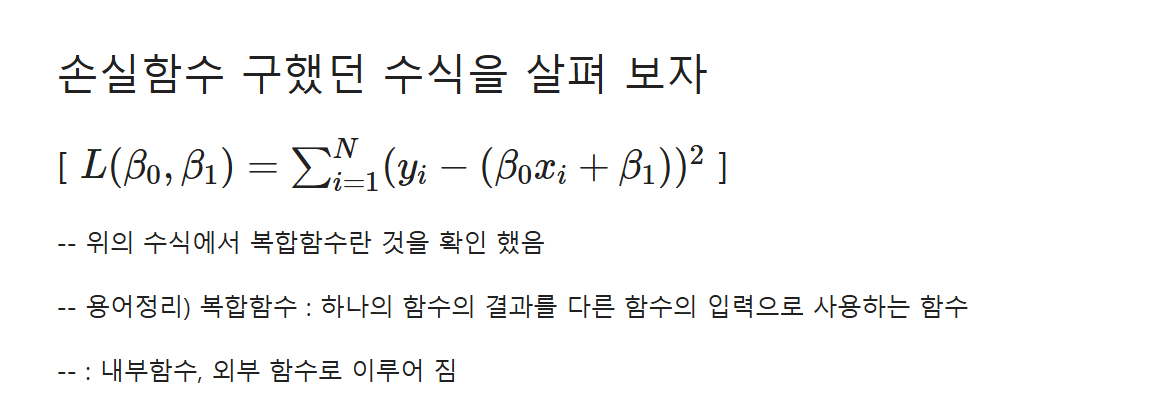</p>

<h1 id="%EC%9D%B4-%EC%86%90%EC%8B%A4-%ED%95%A8%EC%88%98%EC%97%90-%EB%8C%80%ED%95%9C-beta_0%EC%99%80-beta_1%EC%9D%98-%ED%8E%B8%EB%AF%B8%EB%B6%84%EC%9D%84-%EB%B3%B5%ED%95%A9%ED%95%A8%EC%88%98%EB%A5%BC-%EC%A0%81%EC%9A%A9%ED%95%B4%EC%84%9C-%EA%B5%AC%ED%95%B4%EB%B3%B4%EC%9E%90.">이 손실 함수에 대한 beta_0와 beta_1의 편미분을 복합함수를 적용해서 구해보자.¶</h1><p>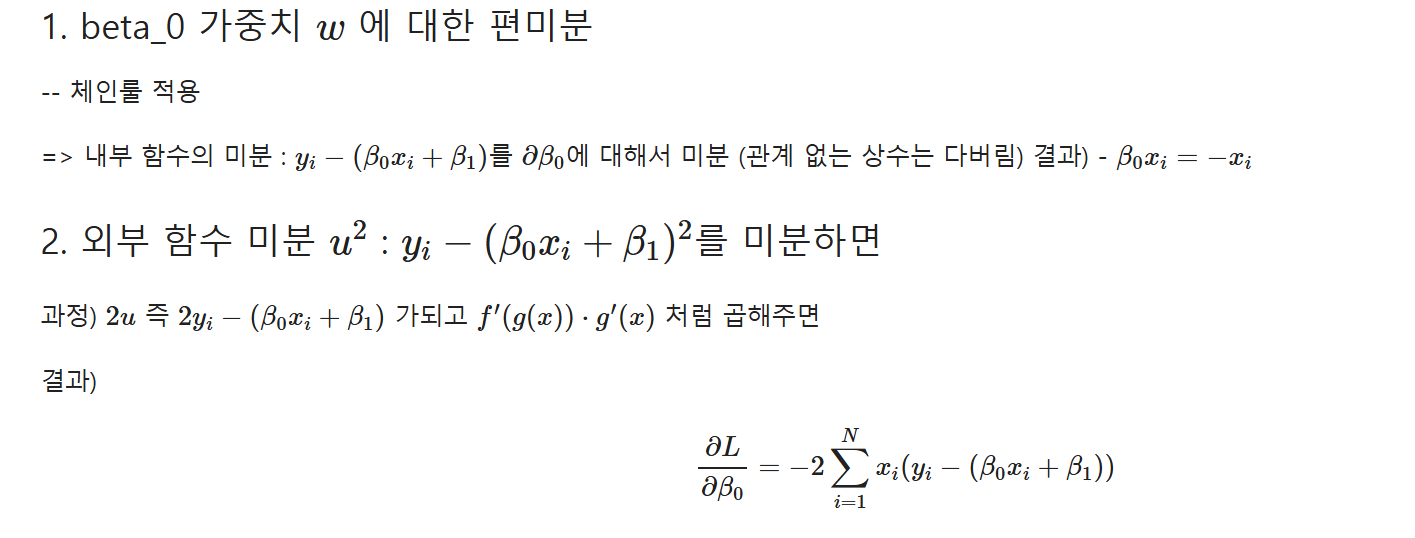</p>

<p>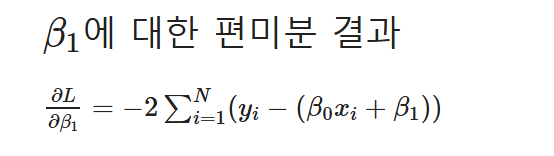</p>

<h2 id="%EA%B2%BD%EC%82%AC-%ED%95%98%EA%B0%95%EB%B2%95(Gradient-Descent)%EC%97%90-%EC%A0%81%EC%9A%A9%ED%95%98%EA%B8%B0">경사 하강법(Gradient Descent)에 적용하기¶</h2><p>-- 의미 :<br />
β0 와 β1
을 가지고 Loss를 최소하 하는 값을 업데이트 하기 위해서 .. 오차를 줄이기 위해서 ...</p>
<p>-- Loss함수를 구한 후 경사하강법을 진행한다. *****</p>

In [20]:
def MSE(x,y,beta_0,beta_1):
    n = len(x)
    '''
    x, y, beta_0, beta_1 을 이용해 loss값을 계산한 뒤 리턴
    '''  
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    #print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted) ** 2
    total_loss = np.sum(squared_loss)
    total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2) / n
    return total_loss

<p>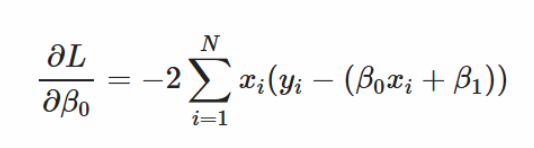</p>

<p>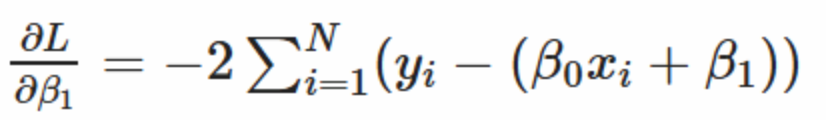</p>

In [21]:
# 손실 함수의 미분을 계산하기 위한 함수
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * sum(x *(y - y_predicted))
    d_beta_1 = -2 * np.sum(y - y_predicted)
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n

In [22]:
#epochs 만큼을 반복하면서 learning_rate(학습률)에 따라서 beta_0, beta_1 을 구하는 함수
def gradient_descent(x,y,beta_0,beta_1,learning_rate,epochs):
    for i in range(epochs):
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        if i % 100 == 0:
            print(f"Epoch : {i} => Loss {MSE(x,y,beta_0,beta_1)}")
    return beta_0, beta_1

In [23]:
beta_0 = 0.5
beta_1 = 2.5
learning_rate = 0.01
epochs = 1000
beta_0,beta_1 = gradient_descent(X,Y,beta_0,beta_1,learning_rate,epochs)
print('*'*30)
print(f'Optimized beta_0 : {beta_0} , beta_a : {beta_1}')

Epoch : 0 => Loss 0.37857411927321694
Epoch : 100 => Loss 0.37218630799287317
Epoch : 200 => Loss 0.3721732366219602
Epoch : 300 => Loss 0.3721678234157438
Epoch : 400 => Loss 0.3721655816614752
Epoch : 500 => Loss 0.372164653290746
Epoch : 600 => Loss 0.37216426882746123
Epoch : 700 => Loss 0.37216410961087554
Epoch : 800 => Loss 0.3721640436750057
Epoch : 900 => Loss 0.37216401636918883
******************************
Optimized beta_0 : 0.4308077359858803 , beta_a : 2.505991529490515


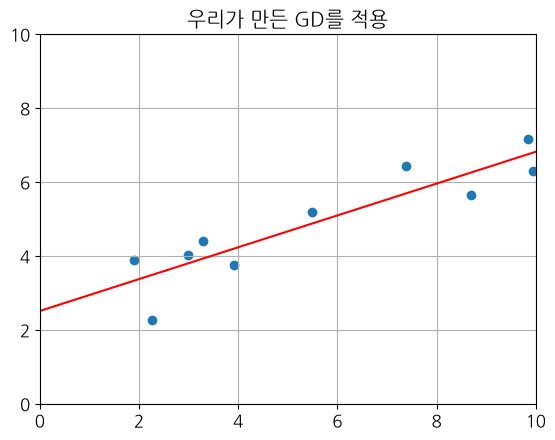

In [24]:
plt.scatter(X, Y)
plt.title('우리가 만든 GD를 적용')
plt.plot([0,10],[beta_1, 10 * beta_0 + beta_1],c='r')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True)
plt.show()

In [25]:
def predict(x_new,beta_0,beta_1):
    return beta_0 * x_new  + beta_1

In [26]:
np.array(X).max()  , np.array(X).min()

(np.float64(9.94589513), np.float64(1.89362433))

In [27]:
x_new = 9.8
y_pred = predict(x_new,beta_0,beta_1)
y_pred

np.float64(6.727907342152141)

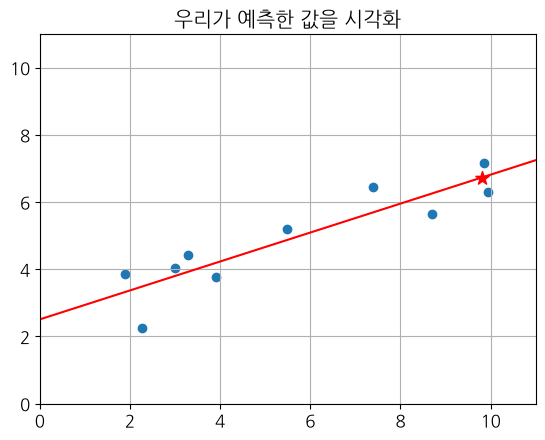

In [28]:
plt.scatter(X, Y)
plt.title('우리가 예측한 값을 시각화')
plt.plot([0,11],[beta_1, 11 * beta_0 + beta_1],c='r')
plt.scatter(x_new,y_pred,color='red', marker='*',s=100)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True)
plt.show()

In [29]:
# 손실 함수의 미분을 계산하기 위한 함수
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * sum(x *(y - y_predicted))
    d_beta_1 = -2 * np.sum(y - y_predicted)
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n

In [30]:
#epochs 만큼을 반복하면서 learning_rate(학습률)에 따라서 beta_0, beta_1 을 구하는 함수
def gradient_descent(x,y,beta_0,beta_1,learning_rate,epochs):
    #시각화를 하기 위해서 리스트들을 좀 선언
    loss_history = []
    beta_0_history = []
    beta_1_history = []
    for i in range(epochs):
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        loss_history.append(MSE(x,y,beta_0,beta_1))
        beta_0_history.append(beta_0)
        beta_1_history.append(beta_1)
        if i % 100 == 0:
            print(f"Epoch : {i} => Loss {MSE(x,y,beta_0,beta_1)}")
    return beta_0, beta_1 , beta_0_history, beta_1_history, loss_history

In [31]:
beta_0 = 0
beta_1 = 0
learning_rate = 0.001
epochs = 2500
beta_0, beta_1 , beta_0_history, beta_1_history, loss_history = gradient_descent(X,Y,beta_0,beta_1,learning_rate,epochs)

Epoch : 0 => Loss 22.27842598431253
Epoch : 100 => Loss 1.5527037642047712
Epoch : 200 => Loss 1.45327306448779
Epoch : 300 => Loss 1.3622175985540552
Epoch : 400 => Loss 1.2788311996241049
Epoch : 500 => Loss 1.2024679472349755
Epoch : 600 => Loss 1.132536323009968
Epoch : 700 => Loss 1.0684946286904657
Epoch : 800 => Loss 1.009846790080048
Epoch : 900 => Loss 0.9561385143977464
Epoch : 1000 => Loss 0.9069537712748547
Epoch : 1100 => Loss 0.8619115701367169
Epoch : 1200 => Loss 0.8206630090067056
Epoch : 1300 => Loss 0.7828885718721128
Epoch : 1400 => Loss 0.7482956536770319
Epoch : 1500 => Loss 0.7166162937705488
Epoch : 1600 => Loss 0.6876051002532819
Epoch : 1700 => Loss 0.6610373491440155
Epoch : 1800 => Loss 0.6367072436423641
Epoch : 1900 => Loss 0.6144263200035163
Epoch : 2000 => Loss 0.5940219876767836
Epoch : 2100 => Loss 0.5753361923997039
Epoch : 2200 => Loss 0.5582241918918758
Epoch : 2300 => Loss 0.5425534346649104
Epoch : 2400 => Loss 0.52820253326363


In [32]:
print('*'*30)
print(f'Optimized beta_0 : {beta_0} , beta_a : {beta_1}')

******************************
Optimized beta_0 : 0.5426246517149599 , beta_a : 1.7075225656673854


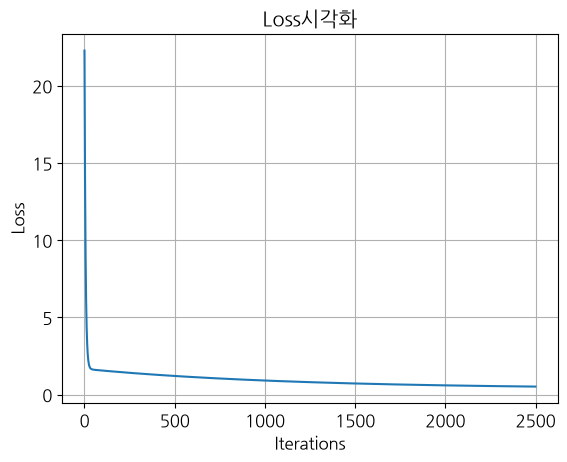

In [33]:
plt.plot(loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss시각화')
plt.grid(True)
plt.show()

<h2 id="%EC%82%AC%EC%9D%B4%ED%82%B7%EB%9F%B0%EC%9D%98-%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80(LinearRegression)-%EB%AA%A8%EB%8D%B8">사이킷런의 선형회귀(LinearRegression) 모델¶</h2>
<p>기울기, 절편을 반환 - 경사하강법 포함!</p>

<p>모델 학습 - fit(훈련데이터X[features],라벨데이터Y[target]) : 지도학습</p>

!pip install scikit-learn
from sklearn.linear_model import LinearRegression # 선형회귀 모델

In [35]:
#!pip list | grep scikit-learn

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [37]:
len(X), len(Y)

(10, 10)

In [38]:
#용어 및 규칙
# 지도학습  : X,y가 필요하고
# 과적합을 방지 하기 위해서 반드시 trainX , trainy (훈련용) , testX , testy (테스용)
# 독립변수, 파라미터, 특성 -> X => , 종속변수, 라벨 -> Y
train_X = np.array(X)
train_Y = np.array(Y)
print(train_X.shape,":",train_Y.shape)
print(train_X.ndim,":",train_Y.ndim)
print(train_X)

(10,) : (10,)
1 : 1
[8.7015376  3.90825773 1.89362433 3.28730045 7.39333004 2.98984649
 2.2575724  9.84450732 9.94589513 5.48321616]


In [39]:
lrmodel = LinearRegression()
#지도학습 -> model.fit(X,y)
# ValueError: Expected 2D array, got 1D array instead: 1차원
# fit(2DX,1DY) 사소하지만 이것을 지켜한다
train_X = np.array(X).reshape(-1,1)
print(train_X.shape,":",train_Y.shape)
print(train_X.ndim,":",train_Y.ndim)
lrmodel.fit(train_X,train_Y)
lrmodel.coef_ , lrmodel.intercept_, type(lrmodel.coef_)

(10, 1) : (10,)
2 : 1


(array([0.43078118]), np.float64(2.506181170893493), numpy.ndarray)

In [40]:
beta_0 = lrmodel.coef_[0]
beta_1 = lrmodel.intercept_
print("beta_0: %f" % beta_0)
print("beta_1: %f" % beta_1)
print("우리가 정의한 Loss 함수 : %f" % loss(X, Y, beta_0, beta_1))
print("우리가 정의한 MSE 함수 : %f" % MSE(X, Y, beta_0, beta_1))

beta_0: 0.430781
beta_1: 2.506181
y_predicted =>[6.2546398  4.18978504 3.32191889 3.92228833 5.6910886  3.79415077
 3.47870087 6.74700964 6.7906856  4.86824749]
우리가 정의한 Loss 함수 : 3.721640
우리가 정의한 MSE 함수 : 0.372164


In [41]:
x_new = 9.8
# ***** 사이킷 런이 원하는 차원으로 변경!
#모델 예측을 해주는 함수 
x_new = np.array(x_new).reshape(-1,1)
y_pred2 = lrmodel.predict(x_new)
print(f"광고료 {x_new} => 판매예측 : {y_pred2}")

광고료 [[9.8]] => 판매예측 : [6.72783672]


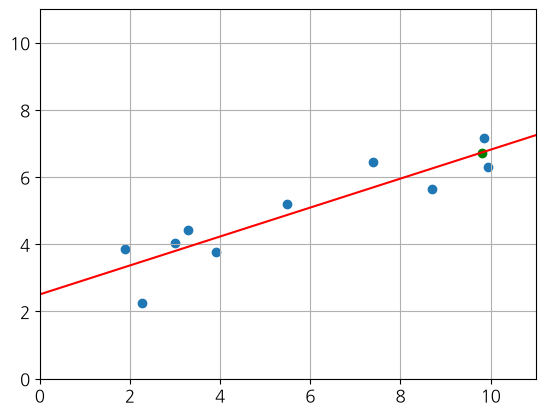

In [42]:
plt.scatter(X, Y)
plt.plot([0, 11], [beta_1, 11 * beta_0 + beta_1], c='r')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True)
plt.scatter(x_new, y_pred2, color='green')
plt.show()

In [43]:
y_pred = lrmodel.predict(train_X)
mse_val = mean_squared_error(train_Y,y_pred)
print(f"사이킷런의 MSE {mse_val}")

사이킷런의 MSE 0.37216399706795633


In [44]:
#한번 해보기 -> 사이킷런의 LinearRegression 을 사용해서
# 
X = [22.1, 25.3, 27.8, 30.0, 33.2, 35.0, 37.5, 28.9, 31.4, 34.6]
Y = [13, 20, 27, 32, 40, 43, 50, 29, 35, 45]
# 1) 지도학습 -> X,y의 변수에 저장 
train_X = np.array(X).reshape(-1,1)
train_Y = np.array(Y)
# 2) 모델을 생성 
lrmodel = LinearRegression()
# 3) 학습진행 -> 경사하강법 
lrmodel.fit(train_X,train_Y)
print(lrmodel.coef_ ,lrmodel.intercept_ , type(lrmodel.coef_))
beta_0 = lrmodel.coef_[0]
beta_1 = lrmodel.intercept_
y_pred = lrmodel.predict(train_X)

[2.43949335] -41.1997066344229 <class 'numpy.ndarray'>


In [45]:
print("beta_0: %f" % beta_0)
print("beta_1: %f" % beta_1)
print("우리가 정의한 Loss 함수 : %f" % MSE(X, Y, beta_0, beta_1))
print("사이킷런 MSE 함수 : %f" % mean_squared_error(Y,y_pred))

beta_0: 2.439493
beta_1: -41.199707
우리가 정의한 Loss 함수 : 0.548621
사이킷런 MSE 함수 : 0.548621


In [46]:
x_new = 37.4
y_pred2 = lrmodel.predict([[x_new]]) # ***** 사이킷 런이 원하는 차원으로 변경!
#새 데이터 포인트 [[37.4]]에 대한 예측된 y 값: [50.03734465]
print(f"새 데이터 포인트 {x_new}에 대한 예측된 y 값: {y_pred2}")

새 데이터 포인트 37.4에 대한 예측된 y 값: [50.03734465]


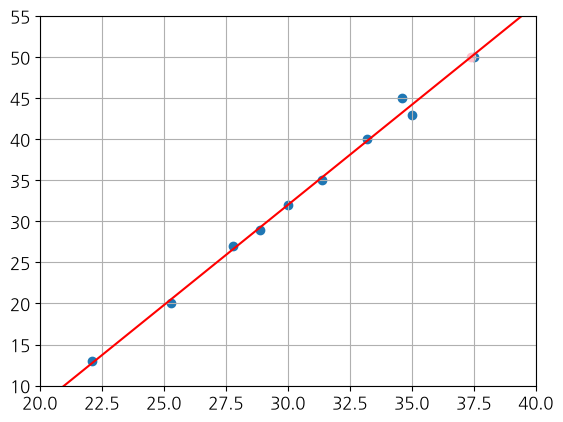

In [47]:
plt.scatter(X, Y)
plt.plot([0,55],[beta_1,55*beta_0 + beta_1],c='r')
plt.xlim(20, 40)
plt.ylim(10, 55)
plt.grid(True)
plt.scatter(x_new, y_pred2, color='pink')
plt.show()

In [48]:
X = [22.1, 25.3, 27.8, 30.0, 33.2, 35.0, 37.5, 28.9, 31.4, 34.6]
Y = [13, 20, 27, 32, 40, 43, 50, 29, 35, 45]
# 연습문제) MSE공식을 적용한 함수  MSE를 만들고 위에서 테스트한
# 기울기(B0)와 절편(B1)을 매개변수로 전달해서 평균제곱오차를 출력하고 
# 그래프로 회귀선을 그려서 시각화 하시오.
#<풀이>
#MSE를 적용한 결과
def MSE(x, y, beta_0, beta_1):
    n = len(x) 
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    #print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted ) ** 2
    mse = np.sum(squared_loss) / n
    #total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2)
    return mse
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * np.sum(x * (y - y_predicted)) #기울기에 대한 편미분
    d_beta_1 = -2 * np.sum(y - y_predicted) # 절편에 대한 편미분
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n 
#epochs 만큼을 반복하면서 learning_rate(학습률)에 따라서 beta_0, beta_1 을 구하는 함수
def gradient_descent(x, y, beta_0, beta_1,learning_rate,epochs):
    for i in range(epochs):
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 하는데 .... 
        # *****************************************************************
        #학습률이 너무 크거나 데이터 스케일이 크면 기울기 업데이트가 너무커져서 
        #inf 즉 무한대가된다.  
        #inf 연산하면 결국 nan이 된다. 
        # *****************************************************************
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        if i % 1000 == 0:
            print(f"beta_0 : {beta_0}")
            print(f"Epoch : {i} => Loss => {MSE(x,y,beta_0,beta_1)}")
    return beta_0, beta_1
beta_0 = 0.5
beta_1 = 2.5
learning_rate = 100
epochs = 10000
beta_0, beta_1 = gradient_descent(X,Y,beta_0,beta_1,learning_rate,epochs)
print("*"*30)
print(f"Optimized beta_0: {beta_0}, beta_1: {beta_1}")
comm="""
Epoch : 0 => Loss91774.72132166216
Epoch : 100 => Loss4.192139518053943e+256
Epoch : 200 => Lossinf
Epoch : 300 => Lossnan
Epoch : 400 => Lossnan
Epoch : 500 => Lossnan
Epoch : 600 => Lossnan
Epoch : 700 => Lossnan
Epoch : 800 => Lossnan
Epoch : 900 => Lossnan
******************************
Optimized beta_0: nan, beta_1: nan
nan이 나오는 이유는 학습률(learning_rate)이 너무 커서 발산하기 때문

"""

beta_0 : 103298.9
Epoch : 0 => Loss => 10213383062079.08
beta_0 : nan
Epoch : 1000 => Loss => nan
beta_0 : nan
Epoch : 2000 => Loss => nan
beta_0 : nan
Epoch : 3000 => Loss => nan
beta_0 : nan
Epoch : 4000 => Loss => nan
beta_0 : nan
Epoch : 5000 => Loss => nan
beta_0 : nan
Epoch : 6000 => Loss => nan
beta_0 : nan
Epoch : 7000 => Loss => nan
beta_0 : nan
Epoch : 8000 => Loss => nan
beta_0 : nan
Epoch : 9000 => Loss => nan
******************************
Optimized beta_0: nan, beta_1: nan


In [49]:
# 스케일링 - X값이 클때 Nan이 발생할 수 있다.
X = [22.1, 25.3, 27.8, 30.0, 33.2, 35.0, 37.5, 28.9, 31.4, 34.6]
Y = [13, 20, 27, 32, 40, 43, 50, 29, 35, 45]
def standardize(data):
    #1)데이터에서 평균을 구한다.
    mean = np.mean(data)
    #2)표준편차를 구한다.
    std = np.std(data)
    #3)데이터의 중심 = 원본데이터 - 평균 을 빼서 구한후 표준편차를 나누어서 반환한다.
    print(f'data - mean : {data - mean}')
    return (data - mean) / std
# 표준화된 X,Y 데이터 
X_std = standardize(X)
Y_std = standardize(Y)
print(X_std[:10])
print(Y_std[:10])

data - mean : [-8.48 -5.28 -2.78 -0.58  2.62  4.42  6.92 -1.68  0.82  4.02]
data - mean : [-20.4 -13.4  -6.4  -1.4   6.6   9.6  16.6  -4.4   1.6  11.6]
[-1.88772869 -1.17537824 -0.61885445 -0.12911352  0.58323693  0.98393406
  1.54045784 -0.37398399  0.1825398   0.89489025]
[-1.85731045 -1.21999804 -0.58268563 -0.12746248  0.60089456  0.87402845
  1.51134086 -0.40059637  0.14567141  1.05611771]


In [50]:
beta_0 = 0.5
beta_1 = 2.5
learning_rate = 0.01
epochs = 10000
beta_0, beta_1 = gradient_descent(X_std,Y_std,beta_0,beta_1,learning_rate,epochs)
print("*"*30)
print(f"Optimized beta_0: {beta_0}, beta_1: {beta_1}")

beta_0 : 0.5099544722704996
Epoch : 0 => Loss => 6.2449663261747865
beta_0 : 0.997723612704083
Epoch : 1000 => Loss => 0.004547591014651296
beta_0 : 0.99772361352498
Epoch : 2000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 3000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 4000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 5000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 6000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 7000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 8000 => Loss => 0.004547591014651282
beta_0 : 0.99772361352498
Epoch : 9000 => Loss => 0.004547591014651282
******************************
Optimized beta_0: 0.99772361352498, beta_1: 4.579328373187678e-16


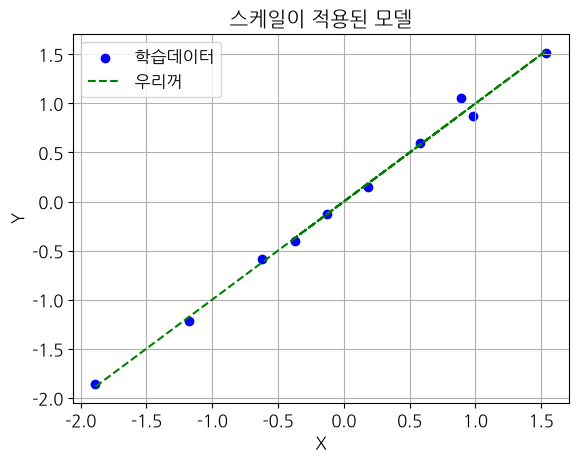

In [51]:
y_pred_me = beta_0 * X_std + beta_1
X2 = np.array(X).reshape(-1,1)
plt.scatter(X_std,Y_std,color='blue',label='학습데이터')
# plt.plot(X2, y_pred, color="red", label="사이킷런")
plt.plot(X_std,y_pred_me,color='green',linestyle='--',label='우리꺼')
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.title("스케일이 적용된 모델")
plt.show()

In [52]:
# 1) 랜덤하게 데이터를 만들어서 
# 2) CSV 저장 -> DataFrame으로 만든 후
# 3) 선형회귀 모델 적용

In [53]:
np.random.seed(1)
# 키 의 가상데이터 
# 평균키 : 170 , 표준편차 10cm , 200명 데이터 
X = np.random.normal(170,10,200)
# 1cm의 키당 0.5씩 증가한다고 가정하고 노이즈를 추가했음 
Y = 0.5 * X + np.random.normal(0,5,200)

In [54]:
# 데이터를 10명 정도 확인
X[:10] , Y[:10]

(array([186.24345364, 163.88243586, 164.71828248, 159.27031378,
        178.65407629, 146.98461303, 187.44811764, 162.38793099,
        173.19039096, 167.50629625]),
 array([91.11733586, 86.06124602, 79.54761408, 89.40954726, 82.66727981,
        64.68886371, 85.47045249, 76.74118757, 80.99961849, 93.53354264]))

In [55]:
# 복습 포인트 데이터를 데이터프레임으로 변환 하는 조건
# 1. 행렬, 이중리스트
# 2. 딕셔너리 -> {'col1':[vector or list],'col2':[vector or list] }
df = pd.DataFrame({'height':X,'weight':Y})
#df.head(2)
#df.info()
#df.isnull().sum()
##컬럼에 이상한 값이 숨어 있는지 살펴보기 위해서 '?' -> info를 확인하고
# df['height'].unique()

In [56]:
import os
os.listdir('dataset')

['rabbit.jpg']

In [57]:
df.to_csv('dataset/linear.csv')

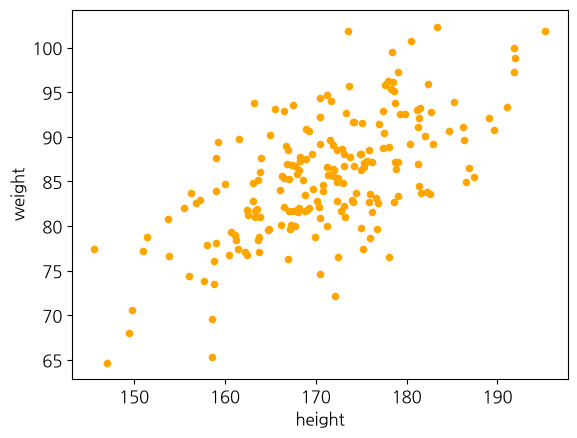

In [58]:
#선형관계 - 키 -> 몸무게를 예측 (선형관계를 시각화)
df.plot(kind='scatter',x='height',y='weight', color='orange')
plt.show()

In [59]:
df2 = pd.read_csv('dataset/linear.csv',index_col=0)
df2.head(2)

,height,weight
0,186.243454,91.117336
1,163.882436,86.061246


In [60]:
# 용어) 하이퍼파라미터 와 파라미터 ************
# 하이퍼파라미터 : 모델링할 때 사용자가 직접 세팅해주는 값
# 파라미터는 매개변수 => lrmodel.coef_[0] 같은 것들
# 예) 가중치, 바이어스, 에폭, 러닝레이트 등

<h2 id="%EC%8A%A4%EC%BC%80%EC%9D%BC%EB%A7%81%EC%9D%B4-%ED%95%84%EC%9A%94%ED%95%9C-%EC%9D%B4%EC%9C%A0">스케일링이 필요한 이유¶</h2>
<p>데이터의 값 폭(범위)이 클경우 하이퍼파라미터 연산시 비용이 많으 들고 훈련이 제대로 되지 않을 수 있다.</p>

<p>이미지 일경우 0 ~ 255 사이의 큰값을 4차원일 경우 ..</p>

<p>지금처럼 범위가 큰 수치일 경우</p>

In [61]:
# df2 numpy 벡터로 각각 저장
# 1) 독립변수 , 종속변수에 각각 데이터를 저장
X = df2['height'].values
Y = df2['weight'].values

Epoch : 0 => Loss 24399437.302922316 ,beta_0 => 29.333113401097766
Epoch : 100 => Loss inf ,beta_0 => 3.7497971764623327e+177
Epoch : 200 => Loss nan ,beta_0 => nan
Epoch : 300 => Loss nan ,beta_0 => nan
Epoch : 400 => Loss nan ,beta_0 => nan
Epoch : 500 => Loss nan ,beta_0 => nan
Epoch : 600 => Loss nan ,beta_0 => nan
Epoch : 700 => Loss nan ,beta_0 => nan
Epoch : 800 => Loss nan ,beta_0 => nan
Epoch : 900 => Loss nan ,beta_0 => nan
Epoch : 1000 => Loss nan ,beta_0 => nan
Epoch : 1100 => Loss nan ,beta_0 => nan
Epoch : 1200 => Loss nan ,beta_0 => nan
Epoch : 1300 => Loss nan ,beta_0 => nan
Epoch : 1400 => Loss nan ,beta_0 => nan
Epoch : 1500 => Loss nan ,beta_0 => nan
Epoch : 1600 => Loss nan ,beta_0 => nan
Epoch : 1700 => Loss nan ,beta_0 => nan
Epoch : 1800 => Loss nan ,beta_0 => nan
Epoch : 1900 => Loss nan ,beta_0 => nan
Epoch : 2000 => Loss nan ,beta_0 => nan
Epoch : 2100 => Loss nan ,beta_0 => nan
Epoch : 2200 => Loss nan ,beta_0 => nan
Epoch : 2300 => Loss nan ,beta_0 => nan
Ep

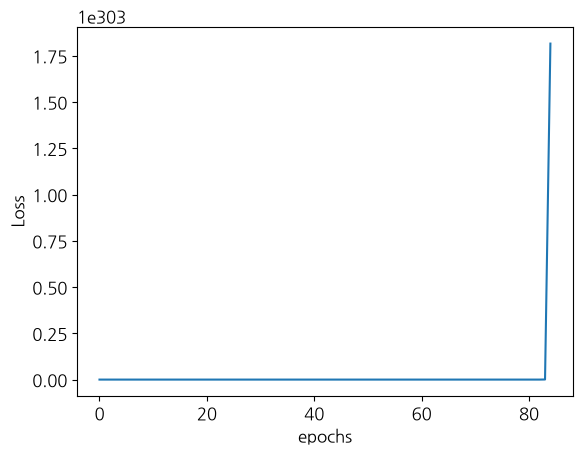

In [62]:
def MSE(x, y, beta_0, beta_1):
    n = len(x) 
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    #print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted ) ** 2
    mse = np.sum(squared_loss) / n
    #total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2)
    return mse
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * np.sum(x * (y - y_predicted)) #기울기에 대한 편미분
    d_beta_1 = -2 * np.sum(y - y_predicted) # 절편에 대한 편미분
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n 
#epochs 만큼을 반복하면서 learning_rate(학습

#epochs 만큼을 반복하면서 learning_rate(학습률)에 따라서 beta_0, beta_1 을 구하는 함수
def gradient_descent(x,y,beta_0,beta_1,learning_rate,epochs):
    #시각화를 하기 위해서 리스트들을 좀 선언
    loss_history = []
    beta_0_history = []
    beta_1_history = []
    for i in range(epochs):
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        loss_history.append(MSE(x,y,beta_0,beta_1))
        beta_0_history.append(beta_0)
        beta_1_history.append(beta_1)
        if i % 100 == 0:
            print(f"Epoch : {i} => Loss {MSE(x,y,beta_0,beta_1)} ,beta_0 => {beta_0}")
    return beta_0, beta_1 , beta_0_history, beta_1_history, loss_history
beta_0 = 0
beta_1 = 0
lr = 0.001
epochs = 2500
beta_0, beta_1 , beta_0_history, beta_1_history, loss_history = \
gradient_descent(X,Y,beta_0,beta_1,lr,epochs)
print(f"B0 => {beta_0} , B1 => {beta_1}")
plt.plot(loss_history)
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.show()
# Loss가 Nan이 나오는 이유 데이터의 스케일(범위)이 크면 경사하강법에서 수치적으로 
# 연산이 안되는 경우가 발생한다.

<h2 id="%ED%8A%B9%EC%84%B1-%EC%8A%A4%EC%BC%80%EC%9D%BC%EB%A7%81(feature-scaling)">특성 스케일링(feature scaling)¶</h2>
<p>데이터의 스케일(범위)이 크면 경사 하강법을 사용할 때 수치적 안정성 문제가 발생 할 수 있다.</p>

<p>특히 선형 회귀 모델에서 데이터가 크게 범위를 벗어나면, 그라디언트(기울기) 계산 시 너무 큰 값이 발생하여 오버플로우(overflow) 또는 안정적이지 않은 수치 계산으로 이어질 수 있다.</p>

<p>해결 책 : 특성 스케일링(feature scaling)</p>

<p>특성 스케일링은 데이터의 범위를 조정하여 모델 학습이 더 안정적으로 수행되도록 하는 기법 (면접 준비용)</p>

<p>표준화(standardization) : 가장 일반적인 스케일 방법</p>


<p>: 각 데이터에서 평균을 빼고, 그 결과를 <나누어서> 데이터의 평균을 0, 표준편차를 1로 만드는 방법</p>

In [63]:
#데이터를 초기화 하자
X = df2['height'].values
Y = df2['weight'].values
X[:10] , Y[:10]

(array([186.24345364, 163.88243586, 164.71828248, 159.27031378,
        178.65407629, 146.98461303, 187.44811764, 162.38793099,
        173.19039096, 167.50629625]),
 array([91.11733586, 86.06124602, 79.54761408, 89.40954726, 82.66727981,
        64.68886371, 85.47045249, 76.74118757, 80.99961849, 93.53354264]))

In [64]:
X.max(),X.min(), Y.max(), Y.min()

(np.float64(195.283257068064),
 np.float64(145.65162235892862),
 np.float64(102.34642590013536),
 np.float64(64.68886371360466))

In [65]:
def standardize(data):
    #1)데이터의 평균 -> np.mean()
    mean = np.mean(data)
    #2)데이터의 표준편차 -> np.std()
    std = np.std(data)
    #3)데이터의 중심 = 원본 - 평균 빼서 구해가지고 표준편차 나누라며?
    #print(f'data - mean: {data-mean}')
    return (data-mean) / std
#X,y 에대해서 각각 표준화
X_std = standardize(X)
Y_std = standardize(Y)
print(X_std[:10])
print(Y_std[:10])

[ 1.66767018 -0.78946036 -0.69761372 -1.29626135  0.83371481 -2.64627014
  1.80004415 -0.95368337  0.23334017 -0.39125407]
[ 0.83436804  0.08241494 -0.8863071   0.58038186 -0.42234337 -3.096134
 -0.00544921 -1.30368519 -0.67036173  1.19371176]


Epoch : 0 => Loss 0.9983663944655177 ,beta_0 => 0.0012787653323646161
Epoch : 100 => Loss 0.8640191362388208 ,beta_0 => 0.11705199500434847
Epoch : 200 => Loss 0.7739995390627707 ,beta_0 => 0.21182011768540382
Epoch : 300 => Loss 0.7136817627069294 ,beta_0 => 0.2893941570547563
Epoch : 400 => Loss 0.6732657393226211 ,beta_0 => 0.35289369058810127
Epoch : 500 => Loss 0.6461849176330997 ,beta_0 => 0.4048723008516974
Epoch : 600 => Loss 0.6280393693586896 ,beta_0 => 0.4474202657673145
Epoch : 700 => Loss 0.6158809154552636 ,beta_0 => 0.48224861745428627
Epoch : 800 => Loss 0.6077341237967161 ,beta_0 => 0.5107579500072555
Epoch : 900 => Loss 0.6022753528991204 ,beta_0 => 0.5340947432589399
Epoch : 1000 => Loss 0.5986176946501613 ,beta_0 => 0.5531974675426452
Epoch : 1100 => Loss 0.596166874837945 ,beta_0 => 0.5688343235204011
Epoch : 1200 => Loss 0.5945246990677888 ,beta_0 => 0.5816341347534865
Epoch : 1300 => Loss 0.5934243565429544 ,beta_0 => 0.5921116353351683
Epoch : 1400 => Loss 0.592

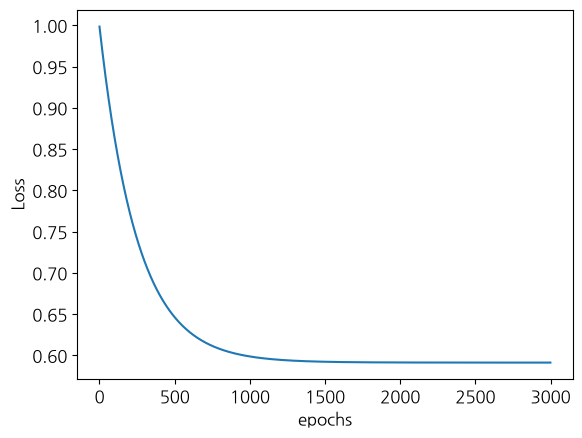

In [66]:
def MSE(x, y, beta_0, beta_1):
    n = len(x) 
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    #print(f"y_predicted =>{y_predicted}")
    squared_loss = (y - y_predicted ) ** 2
    mse = np.sum(squared_loss) / n
    #total_loss = np.sum((y - (beta_0 * x + beta_1)) ** 2)
    return mse
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * np.sum(x * (y - y_predicted)) #기울기에 대한 편미분
    d_beta_1 = -2 * np.sum(y - y_predicted) # 절편에 대한 편미분
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n 
#epochs 만큼을 반복하면서 learning_rate(학습

#epochs 만큼을 반복하면서 learning_rate(학습률)에 따라서 beta_0, beta_1 을 구하는 함수
def gradient_descent(x,y,beta_0,beta_1,learning_rate,epochs):
    #시각화를 하기 위해서 리스트들을 좀 선언
    loss_history = []
    beta_0_history = []
    beta_1_history = []
    for i in range(epochs):
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        loss_history.append(MSE(x,y,beta_0,beta_1))
        beta_0_history.append(beta_0)
        beta_1_history.append(beta_1)
        if i % 100 == 0:
            print(f"Epoch : {i} => Loss {MSE(x,y,beta_0,beta_1)} ,beta_0 => {beta_0}")
    return beta_0, beta_1 , beta_0_history, beta_1_history, loss_history
beta_0 = 0
beta_1 = 0
lr = 0.001
epochs = 3000
beta_0, beta_1 , beta_0_history, beta_1_history, loss_history = \
gradient_descent(X_std,Y_std,beta_0,beta_1,lr,epochs)
print(f"B0 => {beta_0} , B1 => {beta_1}")
plt.plot(loss_history)
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.show()

In [67]:
#<복습용 연습문제> - 팀별 스터디 겸 코딩 완료후 카페에 답글로 올려주세요.
#1. 스케일링이 적용된 beta_0,  beta_1 찾은것을 가지고 가장 잘 설명한 직선을 그리시오
#2. 새로운 키 값을 표준화한 후, 학습된 모델을 사용하여 몸무게를 예측
# 키가 177cm인 사람의 예측 몸무게: 88.07kg
# 새로운 데이터 : 키
#3. 사이킷런의 LinearRegression 모델로 구현 해보기 - 스케일링 적용 안하고 해보기

Epoch 0: Loss = 0.9983663944655177
Epoch 100: Loss = 0.8640191362388208
Epoch 200: Loss = 0.7739995390627707
Epoch 300: Loss = 0.7136817627069294
Epoch 400: Loss = 0.6732657393226211
Epoch 500: Loss = 0.6461849176330997
Epoch 600: Loss = 0.6280393693586896
Epoch 700: Loss = 0.6158809154552636
Epoch 800: Loss = 0.6077341237967161
Epoch 900: Loss = 0.6022753528991204
Epoch 1000: Loss = 0.5986176946501613
Epoch 1100: Loss = 0.596166874837945
Epoch 1200: Loss = 0.5945246990677888
Epoch 1300: Loss = 0.5934243565429544
Epoch 1400: Loss = 0.5926870702585247
Epoch 1500: Loss = 0.592193050393856
Epoch 1600: Loss = 0.5918620315863161
Epoch 1700: Loss = 0.5916402319001464
Epoch 1800: Loss = 0.5914916146625019
Epoch 1900: Loss = 0.5913920334425891
Epoch 2000: Loss = 0.5913253088854883
Epoch 2100: Loss = 0.5912805999883272
Epoch 2200: Loss = 0.5912506427196358
Epoch 2300: Loss = 0.5912305698034059
Epoch 2400: Loss = 0.5912171199134937
Epoch 2500: Loss = 0.5912081077930534
Epoch 2600: Loss = 0.59120

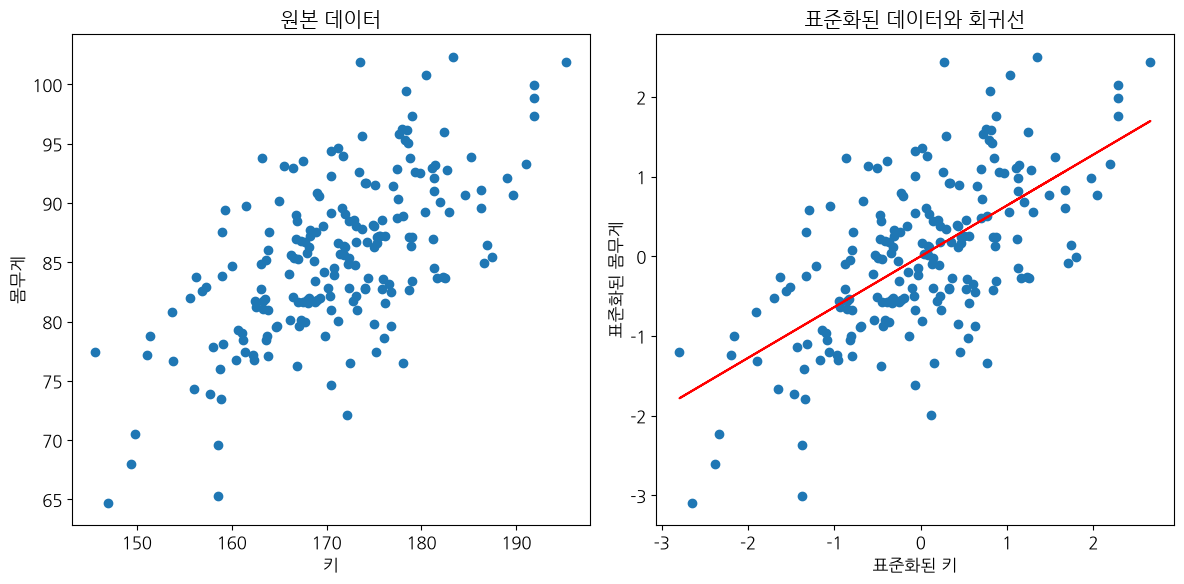

In [68]:
#<복습용 연습문제>
#1. 스케일링이 적용된 beta_0,  beta_1 찾은것을 가지고 가장 잘 설명한 직선을 그리시오
#2. 새로운 키 값을 표준화한 후, 학습된 모델을 사용하여 몸무게를 예측
def MSE(x, y, beta_0, beta_1):
    n = len(x) # 전체 길이
    x = np.array(x)
    y = np.array(y)
    y_pred = beta_0 * x + beta_1 # 예측값
    #오차 = 실제값 - 예측값
    seq_loss = (y - y_pred) ** 2
    #평균구함 
    mse = np.sum(seq_loss) / n
    return mse
def gradients(x, y, beta_0, beta_1):
    n = len(x) # 전체 길이
    x = np.array(x)
    y = np.array(y)
    y_pred = beta_0 * x + beta_1 # 예측값
    d_beta_0 = -2 * np.sum(x * (y - y_pred)) # 기울기에 대한 편미분
    d_beta_1 = -2 * np.sum(y - y_pred) # 절편에 대한 편미분
    return d_beta_0 / n , d_beta_1 / n
def gradient_descent(x,y,beta_0, beta_1,learning_rate, epochs):
    loss_history = []
    beta_0_history = []
    beta_1_history = []
    for i in range(epochs):
        d_beta_0 , d_beta_1 = gradients(x,y,beta_0,beta_1)
        beta_0 -= learning_rate * d_beta_0
        beta_1 -= learning_rate * d_beta_1
        loss_history.append(MSE(x, y, beta_0, beta_1))
        beta_0_history.append(beta_0)
        beta_1_history.append(beta_1)
        if i % 100 == 0:
            print(f"Epoch {i}: Loss = {MSE(x, y, beta_0, beta_1)}")
    return beta_0, beta_1 , beta_0_history, beta_1_history, loss_history 
beta_0 = 0 
beta_1 = 0 
lr = 0.001 
epochs = 3000
beta_0, beta_1 , beta_0_history, beta_1_history, loss_history = \
gradient_descent(X_std,Y_std,beta_0,beta_1,lr,epochs)
print(f"B0 => {beta_0} , B1 => {beta_1}")
# 가장 낮은 손실 값의 인덱스 찾기 ********** np.argmin():최소값 np.min()의 인덱스 위치를 반환
min_loss_index = np.argmin(loss_history)
# 최적의 beta_0와 beta_1 값 찾기
optimal_beta_0 = beta_0_history[min_loss_index]
optimal_beta_1 = beta_1_history[min_loss_index]
print(f'가장 최적화된 beta_0와 {optimal_beta_0}')
print(f'가장 최적화된 beta_1와 {optimal_beta_1}')
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X, Y)
plt.title("원본 데이터")
plt.xlabel("키")
plt.ylabel("몸무게")

plt.subplot(1, 2, 2)
plt.scatter(X_std, Y_std)
plt.plot(X_std, optimal_beta_0 * X_std + optimal_beta_1, color='red')  # 회귀선
plt.title("표준화된 데이터와 회귀선")
plt.xlabel("표준화된 키")
plt.ylabel("표준화된 몸무게")
plt.tight_layout()
plt.show()

In [69]:
# 키가 177cm인 사람의 예측 몸무게: 88.07kg
# 새로운 데이터 : 키
# new_height -> 새로운 키 
# mean_X , mean_Y -> X,Y 데이터의 평균 
# std_X , std_Y-> X,Y 데이터의 표준편차 
# beta_0 , beta_1 -> 최적화 된 기울기와 절편 
# 다한 다음에 예측된 몸무게 값 돌려주면 됨 
def predict(new_height, mean_X, std_X, mean_Y, std_Y, beta_0, beta_1):
    stand_height = (new_height - mean_X) / std_X # 키를 표준화
    stand_weight = beta_0 * stand_height + beta_1 # 몸무게 표준화 # 예측값(몸무게)구하기 위해서 beta_0 * X + beta_1 
     # 스케일된 데이터를 다시 돌려줘야 정상적으로 볼것 아닌가!!!!!
    predicted_weight = stand_weight * std_Y + mean_Y # 예측된 몸무게를 스케일로 변환
    return predicted_weight
new_height = 177
predicted_weight = predict(new_height, np.mean(X), np.std(X), np.mean(Y), np.std(Y), 
                           optimal_beta_0, optimal_beta_1)
print(f"키가 {new_height}cm인 사람의 예측 몸무게: {predicted_weight:.2f}kg")

키가 177cm인 사람의 예측 몸무게: 88.30kg
